In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut

In [2]:
# Generate the simulated data exactly as specified in the question
rng = np.random.default_rng(1)
x = rng.normal(size=100)                      # 100 draws from a standard normal distribution
y = x - 2 * x**2 + rng.normal(size=100)       # true relationship: quadratic in x, plus noise

print("n (number of observations) =", len(x))

n (number of observations) = 100


**n and p:**

- **n = 100** the number of simulated observations.
- **p = 2** the model is built from two predictor terms, X and X^2, even though both derive from a single underlying random variable X.

## (b) Scatterplot of X against Y

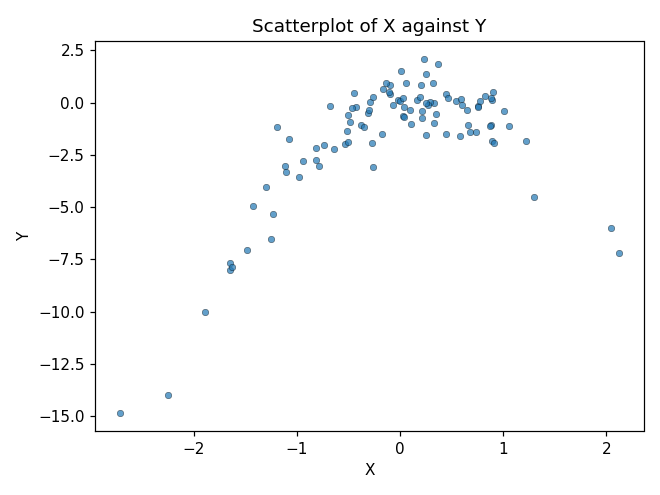

In [2]:
plt.figure(figsize=(6,4.5))
plt.scatter(x, y, s=18, alpha=0.7, edgecolor='k', linewidth=0.3)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatterplot of X against Y')
plt.show()

**Comment:** The relationship between X and Y is **not linear** it traces out a downward-opening parabola. Y rises as X moves up from very negative values, peaks around X ~ 0.25, then falls again as X increases further.

## (c) LOOCV errors for four polynomial models

In [3]:
def loocv_error(x, y, degree):
    """
    Compute the Leave-One-Out Cross-Validation mean squared error for a
    polynomial regression of the given degree (predictors X, X^2, ..., X^degree),
    fit by ordinary least squares.

    For each of the n observations:
      1. Leave that single observation out.
      2. Fit the model on the remaining n-1 observations.
      3. Predict the left-out observation and record its squared error.
    Average the n squared errors to get the LOOCV MSE.
    """
    n = len(x)
    errors = np.zeros(n)
    loo = LeaveOneOut()
    X_full = np.column_stack([x**d for d in range(1, degree + 1)])  # [X, X^2, ..., X^degree]
    for train_idx, test_idx in loo.split(X_full):
        model = LinearRegression()
        model.fit(X_full[train_idx], y[train_idx])
        pred = model.predict(X_full[test_idx])
        errors[test_idx] = (y[test_idx] - pred) ** 2
    return errors.mean()

np.random.seed(1)

loocv_errors_c = {}
for degree in [1, 2, 3, 4]:
    loocv_errors_c[degree] = loocv_error(x, y, degree)
    print(f"Model {degree} (degree {degree} polynomial): LOOCV MSE = {loocv_errors_c[degree]:.4f}")

Model 1 (degree 1 polynomial): LOOCV MSE = 6.6330
Model 2 (degree 2 polynomial): LOOCV MSE = 1.1229
Model 3 (degree 3 polynomial): LOOCV MSE = 1.3018
Model 4 (degree 4 polynomial): LOOCV MSE = 1.3324


## (d) Repeat (c) using another random seed

In [4]:
rng2 = np.random.default_rng(42)
x2 = rng2.normal(size=100)
y2 = x2 - 2 * x2**2 + rng2.normal(size=100)

loocv_errors_d = {}
for degree in [1, 2, 3, 4]:
    loocv_errors_d[degree] = loocv_error(x2, y2, degree)
    print(f"Model {degree} (degree {degree} polynomial): LOOCV MSE = {loocv_errors_d[degree]:.4f}")

Model 1 (degree 1 polynomial): LOOCV MSE = 4.2519
Model 2 (degree 2 polynomial): LOOCV MSE = 0.9640
Model 3 (degree 3 polynomial): LOOCV MSE = 0.9913
Model 4 (degree 4 polynomial): LOOCV MSE = 1.0182


**Are the results the same as (c)? Why?**

numerical LOOCV values are **different** from part (c), for instance, Model 2's LOOCV MSE is 1.1229 in (c) but 0.9640 here, because seed 42 produces an entirely different draw of X and a different realization of the noise epsilon, so the dataset itself has changed.

However, the **qualitative conclusion is identical**: in both (c) and (d), Model 2 (quadratic) has by far the smallest LOOCV error, Model 1 (linear) is the worst, and Models 3-4 sit slightly above Model 2.

## (e) Which model had the smallest LOOCV error?

**Model 2** (the quadratic model, Y = b0 + b1*X + b2*X^2 + epsilon) had the smallest LOOCV error in both (c) (1.1229) and (d) (0.9640).

**Is this expected?** Yes. The data was generated from a model that is *exactly* quadratic in X, so Model 2 is correctly specified. Model 1 is too simple to capture the curvature and clearly underfits (much higher LOOCV error). Models 3 and 4 are flexible enough to also fit the quadratic pattern, but their extra terms (X^3, and X^3+X^4) have true coefficients of zero, so including them adds a small amount of variance without reducing bias any further, giving them slightly higher LOOCV error than the exactly-correct Model 2, though nowhere near as bad as the underfit Model 1.

## (f) Statistical significance of the coefficients

In [5]:
for degree in [1, 2, 3, 4]:
    X_design = np.column_stack([x**d for d in range(1, degree + 1)])
    X_design = sm.add_constant(X_design)   # add the intercept column
    ols_model = sm.OLS(y, X_design).fit()
    print(f"\n=== Model with degree {degree} ===")
    print(ols_model.summary().tables[1])


=== Model with degree 1 ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4650      0.247     -5.937      0.000      -1.955      -0.975
x1             1.9494      0.289      6.752      0.000       1.376       2.522

=== Model with degree 2 ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0728      0.119     -0.611      0.543      -0.309       0.164
x1             0.9663      0.126      7.647      0.000       0.715       1.217
x2            -2.0047      0.091    -22.072      0.000      -2.185      -1.824

=== Model with degree 3 ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0572      0.120     -0.477 